### Imports

In [20]:
import gc
import os
import json
import numpy as np
import random

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import importlib
import helper_utils
importlib.reload(helper_utils)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [21]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## Training efficiency experiment

In [22]:
# Training-time image transforms.
TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    # Match ImageNet normalization because the backbones start from ImageNet weights.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
# Use the same transform settings in trainning
trainset = datasets.Food101(root="../data", split="train", transform=TRAIN_TRANSFORM, download=False) 

# Quick dataset-level checks
print("Train dataset size:", len(trainset))

Train dataset size: 75750


In [24]:
cpu_cores = os.cpu_count()
print(f"Number of available CPU cores: {cpu_cores}")

Number of available CPU cores: 14


### Test num_workers

In [25]:
workers_to_test = [0, 2, 4, 8]

In [26]:
def experiment_workers(workers_to_test, trainset, device):
    # Initialize a dictionary to store the results
    worker_times = {}

    # Loop through each worker number you want to test
    for nw in workers_to_test:
        print(f"--- Testing Number of Workers = {nw} ---")
        
        # Create a new DataLoader instance for each specific test.
        loader = DataLoader(trainset, 
                            batch_size=64, 
                            shuffle=True,
                            # The 'num_workers' is set to the current value in the loop.
                            num_workers=nw
                        )
        
        # Handle potential runtime errors
        try:
            # Time the data loading for one epoch and save it to the dictionary
            worker_times[nw] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs (often from running out of shared memory)
            print(f"\n❌ ERROR with {nw} workers. Likely a shared memory issue.")
            worker_times[nw] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return worker_times

In [ ]:
# Run the experiment to measure the data loading time for different numbers of workers.
worker_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name='worker_times', 
    # The actual function that contains the experiment's logic.
    experiment_fcn=experiment_workers, 
    # The parameters to iterate over; in this case, a list of worker counts.
    cases=workers_to_test, 
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (e.g., 'cpu' or 'mps') to be used.
    device=device,
    # If False, the function will load results from the cache if they exist.
    # If True, it will force the experiment to run again and overwrite any old results.
    rerun=True
)

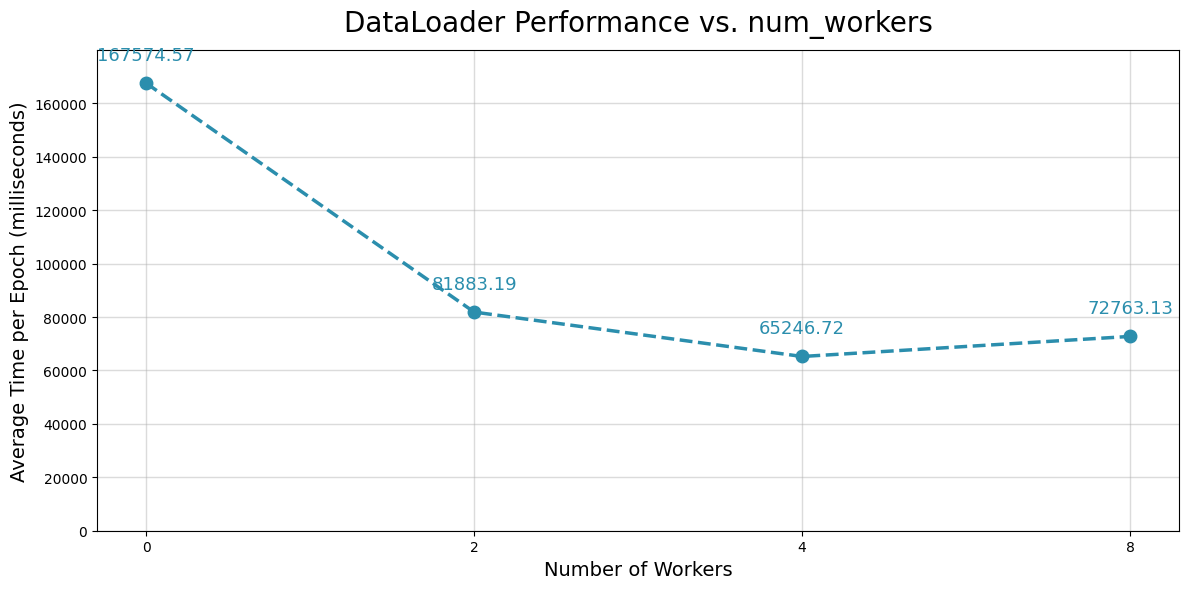

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. num_workers'}, xlabel='Number of Workers', ylabel='Average Time per Epoch (milliseconds)'>)

In [28]:
helper_utils.plot_performance_summary(
    worker_times, 
    title="DataLoader Performance vs. num_workers", 
    xlabel="Number of Workers", 
    ylabel="Average Time per Epoch (milliseconds)"
)

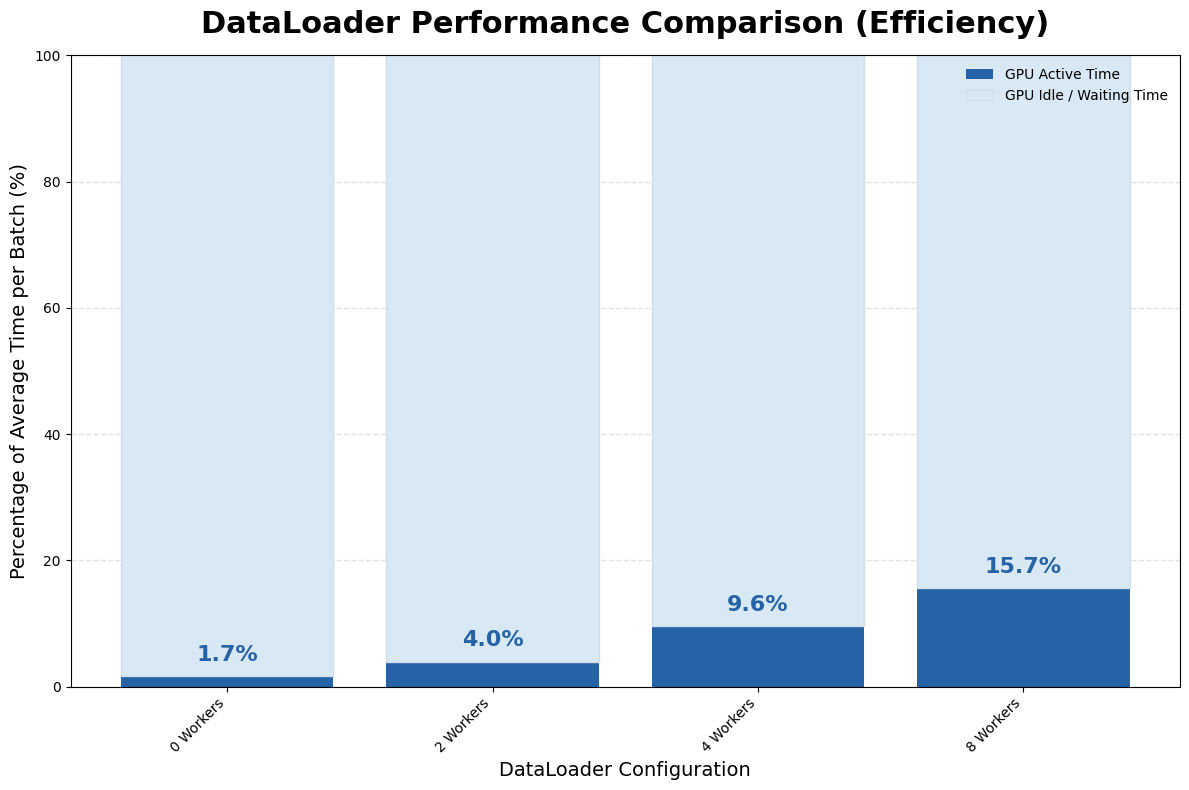

In [29]:
# Create the dictionary of loaders iteratively using a dictionary comprehension
# for each number in the 'workers_to_test' list.
loaders_to_compare = {
    f"{nw} Workers": DataLoader(trainset, batch_size=64, num_workers=nw) 
    for nw in workers_to_test
}

# Pass the generated dictionary to the plotting function.
helper_utils.visualize_dataloader_efficiency(loaders_to_compare, device)

# Clean up and release memory.
del loaders_to_compare
gc.collect()

# Clear the PyTorch MPS cache to free up GPU memory.
if torch.mps.is_available():
    torch.mps.empty_cache()

### Test batch_size

In [30]:
batch_sizes_to_test = [ 32, 64, 128, 256]

In [31]:
def experiment_batch_sizes(batch_sizes_to_test, trainset, device):
    # Initialize a dictionary to store the results
    batch_size_times = {}

    # Loop through each batch size you want to test
    for bs in batch_sizes_to_test:
        print(f"--- Testing Batch Size = {bs} ---")
        
        # Create a new DataLoader instance for each specific test.
        loader = DataLoader(trainset, 
                            # The 'batch_size' is set to the current value in the loop.
                            batch_size=bs, 
                            shuffle=True,
                            num_workers=4 # Use the most efficient num_workers parameter
                        )
        
        # Handle potential runtime errors, especially out-of-memory
        try:
            # Time the data loading for one epoch and save it to the dictionary
            batch_size_times[bs] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs (often from running out of GPU memory),
            print(f"\n❌ ERROR with batch size {bs}. Likely a GPU memory issue.")
            batch_size_times[bs] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        # ensuring each test runs in a clean environment.
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory.
        if torch.mps.is_available():
            torch.mps.empty_cache()
        
    return batch_size_times

In [ ]:
# Run the experiment to measure the data loading time for different batch sizes.
batch_size_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="batch_size_times", 
    # The actual function that contains the experiment's logic.
    experiment_fcn=experiment_batch_sizes,
    # The parameters to iterate over; in this case, a list of different batch sizes.
    cases=batch_sizes_to_test,
    # The dataset required by the experiment function.
    trainset=trainset,
    # The computation device (e.g., 'cpu' or 'mps') to be used.
    device=device,
    # If False, the function will load results from the cache if they exist.
    # If True, it will force the experiment to run again and overwrite any old results.
    rerun=True
)

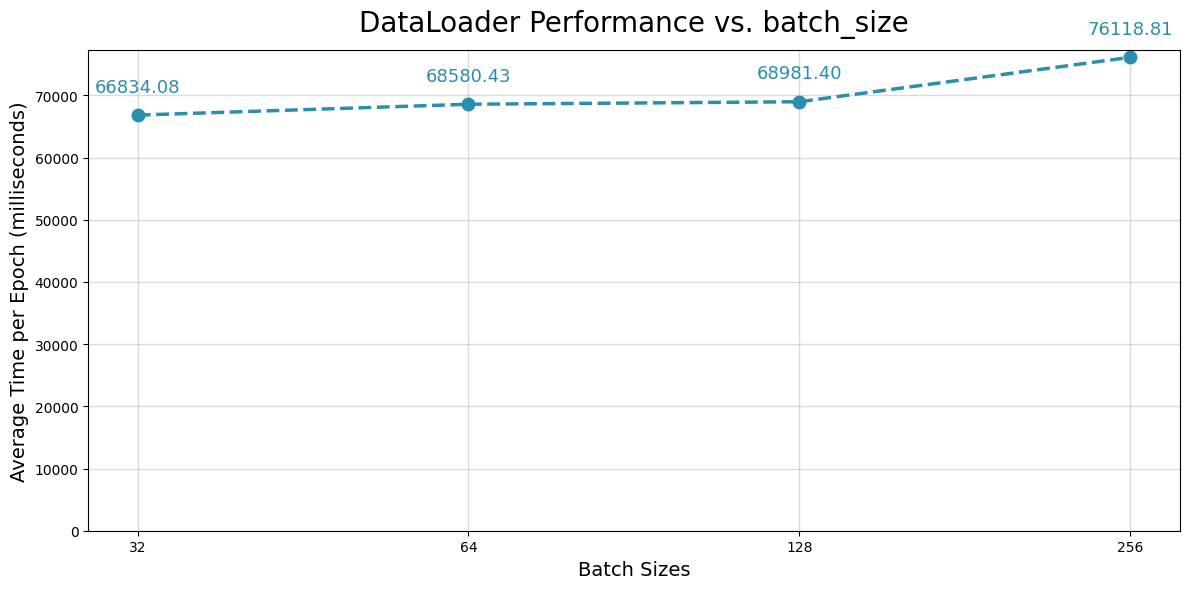

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. batch_size'}, xlabel='Batch Sizes', ylabel='Average Time per Epoch (milliseconds)'>)

In [33]:
helper_utils.plot_performance_summary(
    batch_size_times, 
    title="DataLoader Performance vs. batch_size", 
    xlabel="Batch Sizes", 
    ylabel="Average Time per Epoch (milliseconds)"
)

### Test pin_memory

In [34]:
pin_memory_settings = [False, True]

In [35]:
def experiment_pin_memory(pin_memory_settings, trainset, device):
    # Initialize a dictionary to store the results
    pin_memory_times = {}

    # Loop through each pin_memory setting
    for setting in pin_memory_settings:
        print(f"--- Testing with pin_memory = {setting} ---")
        
        # Create a DataLoader with the current pin_memory setting
        loader = DataLoader(trainset,
                            batch_size=32, # Use the most efficient batch_size parameter
                            num_workers=4, # Use the most efficient num_workers parameter
                            shuffle=True,
                            # The 'pin_memory' is set to the current boolean value in the loop.
                            pin_memory=setting
                        )
        
        try:
            # Measure performance and store the result in the dictionary
            pin_memory_times[setting] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # Print an error message if an exception occurs
            print(f"\n❌ An error occurred with pin_memory = {setting}: {e}")
            pin_memory_times[setting] = float('inf')
            
        # --- Memory Cleanup for each iteration ---
        del loader
        gc.collect()
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return pin_memory_times

In [ ]:
# Run the experiment to measure the data loading time for pin memory either set as False or True.
pin_memory_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="pin_memory_times",
    # The actual function that contains the experiment's logic.
    experiment_fcn=experiment_pin_memory,
    # The parameters to iterate over; in this case, a list of boolean values for pin memory.
    cases=pin_memory_settings,
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (e.g., 'cpu' or 'mps') to be used.
    device=device,
    # If False, the function will load results from the cache if they exist.
    # If True, it will force the experiment to run again and overwrite any old results.
    rerun=False
)

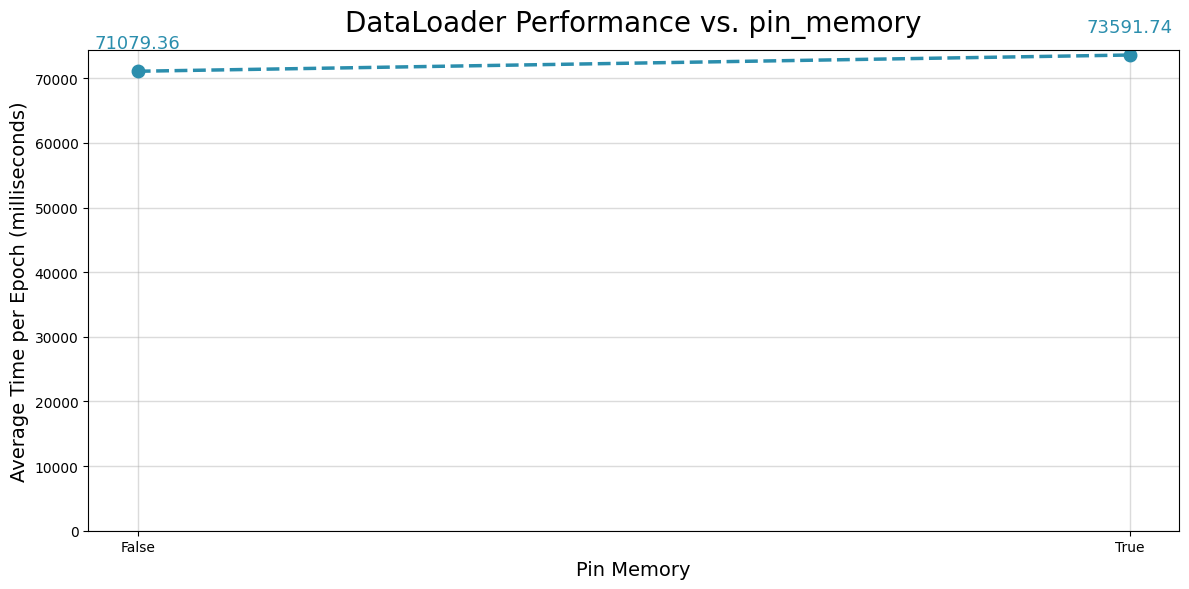

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. pin_memory'}, xlabel='Pin Memory', ylabel='Average Time per Epoch (milliseconds)'>)

In [37]:
helper_utils.plot_performance_summary(
    pin_memory_times, 
    title="DataLoader Performance vs. pin_memory", 
    xlabel="Pin Memory", 
    ylabel="Average Time per Epoch (milliseconds)"
)

### Test prefetch_factor

In [38]:
# Define the list of prefetch_factor values to test
prefetch_factors_to_test = [2, 4, 6, 8]

In [39]:
def experiment_prefetch_factor(prefetch_factors_to_test, trainset, device):
    # Initialize a dictionary to store the results
    prefetch_factor_times = {}

    # Loop through each prefetch factor you want to test
    for pf in prefetch_factors_to_test:
        print(f"--- Testing prefetch_factor = {pf} ---")
        
        # Create a new DataLoader instance for each specific test, using the optimal settings
        loader = DataLoader(trainset, 
                            batch_size=32, # Use the most efficient batch_size parameter
                            shuffle=True, 
                            num_workers=4, # Use the most efficient num_workers parameter
                            pin_memory=False, # Use the most efficient pin_memory choice
                            # The 'prefetch_factor' is set to the current value in the loop.
                            prefetch_factor=pf
                        )
        
        # Handle potential runtime errors
        try:
            # Time the data loading for one epoch and save it to the dictionary
            prefetch_factor_times[pf] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs, record it.
            print(f"\n❌ ERROR with prefetch_factor {pf}: {e}")
            prefetch_factor_times[pf] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        # ensuring each test runs in a clean environment.
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory.
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return prefetch_factor_times

In [ ]:
# Run the experiment to measure the data loading time for different prefetch factor.
prefetch_factor_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="prefetch_factor_times", 
    # The actual function that contains the experiment's logic.
    experiment_fcn=experiment_prefetch_factor,
    # The parameters to iterate over; in this case, a list of different prefetch factor.
    cases=prefetch_factors_to_test,
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (e.g., 'cpu' or 'mps') to be used.
    device=device,
    # If False, the function will load results from the cache if they exist.
    # If True, it will force the experiment to run again and overwrite any old results.
    rerun=False
)

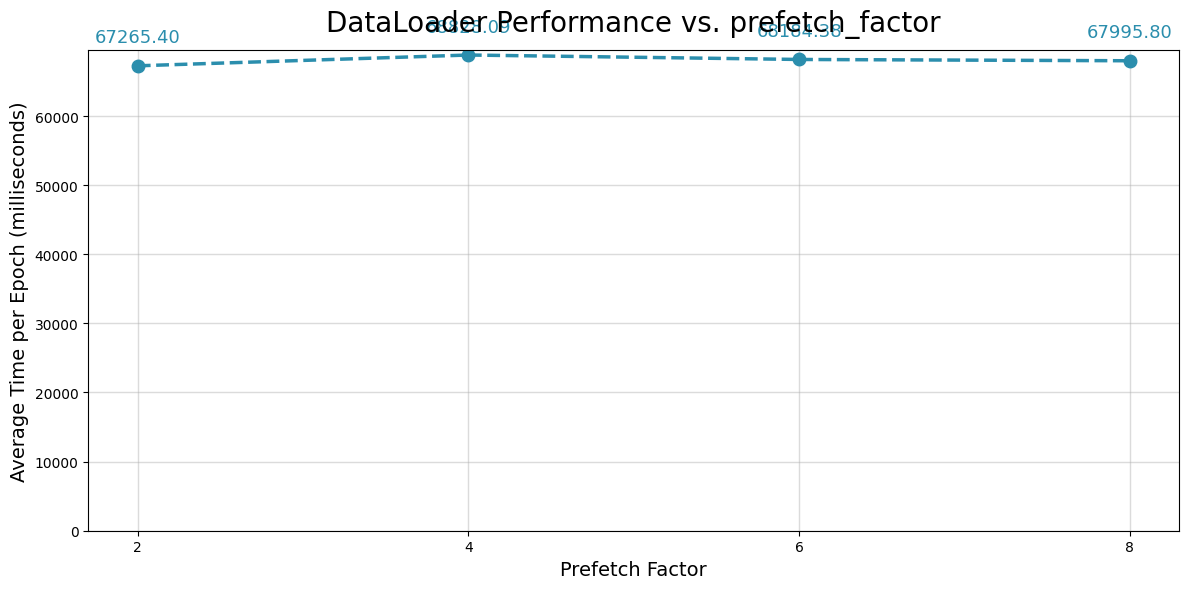

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. prefetch_factor'}, xlabel='Prefetch Factor', ylabel='Average Time per Epoch (milliseconds)'>)

In [41]:
helper_utils.plot_performance_summary(
    prefetch_factor_times, 
    title="DataLoader Performance vs. prefetch_factor", 
    xlabel="Prefetch Factor", 
    ylabel="Average Time per Epoch (milliseconds)"
)